#Dijkstra algorithm

## Documentation of Dijkstra algorithm using Networkx
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.weighted.dijkstra_path.html

##Method and parameters


**dijkstra_path(G, source, target, weight='weight')**

Returns the shortest weighted path from source to target in G.

Uses Dijkstra’s Method to compute the shortest weighted path between two nodes in a graph.

Parameters:
* G: graph. A NetworkX graph
* source:node. Starting node
* target: node. Ending node
* weight: string or function.

Return:
* Path: list. List of nodes in a shortest path.


## Example of Dijkstra's algorithm

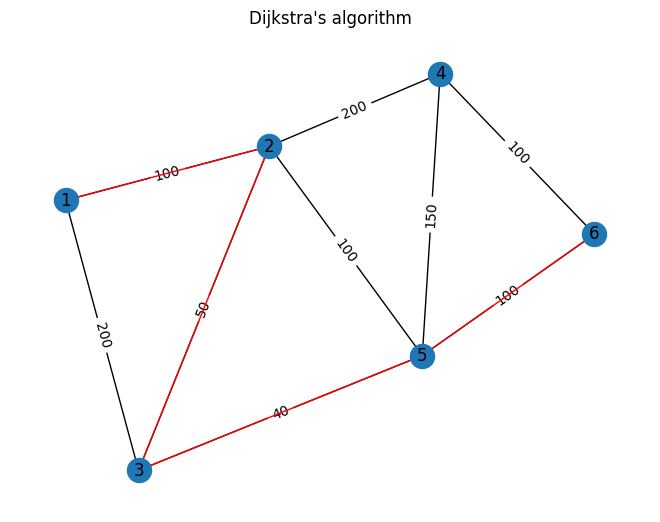

Dijkstra's algorithm
The nodes of the shortest path are: ['1', '2', '3', '5', '6']
The total lenght of the shortest path is: 290


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Data
## Graph Data given as a dictionary
vdicData = {"1" : [("2", 100), ("3", 200)],
            "2" : [("1", 100), ("3", 50), ("4", 200), ("5", 100)],
            "3" : [("1", 200), ("2", 50), ("5", 40)],
            "4" : [("2", 200), ("5", 150), ("6", 100)],
            "5" : [("2", 100), ("3", 40), ("4", 150), ("6", 100)],
            "6" : [("4", 100), ("5", 100)],
            }
# Other data
vsGraphTitle = "Dijkstra's algorithm"
vsStartingNode = "1"
vsEndingNode = "6"
vlstShortestPath = []

# Functions or methods
## Define functions that will be used
def mbImportDataFromDictionary(poGraph, pdicData):
  # This function imports data from a dictionary to a graph.
  lstNodes = list(pdicData.keys())
  for iLoop1 in range(len(lstNodes)):
    sStartingNode = lstNodes[iLoop1]
    lstConectionsNode = pdicData[sStartingNode]
    for iLoop2 in range(len(lstConectionsNode)):
      sEndingNode = lstConectionsNode[iLoop2][0]
      iEdgeWeight = lstConectionsNode[iLoop2][1]
      # Add edge by edge
      poGraph.add_edge(sStartingNode, sEndingNode, weight = iEdgeWeight)

def mlstCreateEdgesFromPath(plstNodesPath):
  # This function creates a list of edges from a list of nodes
  # that creates a path
  lstEdges = []
  for iLoop in range(len(plstNodesPath)):
    if iLoop < len(plstNodesPath) - 1:
      sStartingNode = plstNodesPath[iLoop]
      sEndingNode = plstNodesPath[iLoop + 1]
      lstEdges.append((sStartingNode, sEndingNode))
  return lstEdges

def mbChangeEdgeColor(poGraph, psStartingNode, psEndingNode, psColor="red"):
  # This function changes the color of an edge, default color is red
  poGraph.edges[psStartingNode, psEndingNode]["color"] = psColor

def mbDrawGraph(poGraph, plstPath=[], psTitle = ""):
  # This function draws a graph with tags and colors a path (optional)
  pos = nx.spring_layout(poGraph, seed = 100) # Fix positions of nodes
  nx.draw(poGraph, pos = pos, with_labels = True, )
  # Add tag to each edge
  labels = nx.get_edge_attributes(poGraph,'weight') # get information from graph
  nx.draw_networkx_edge_labels(poGraph, pos, edge_labels=labels)
  if psTitle != "":
    plt.title(psTitle)


  # Color only if path is given
  if len(plstPath) > 0:
    # Apply color
    for iLoop in range(len(plstPath)):
      sEdge = plstPath[iLoop]
      if sEdge in poGraph.edges:
        sElem1 = sEdge[0]
        sElem2 = sEdge[1]
        mbChangeEdgeColor(poGraph, sElem1, sElem2, "red")
      else:
        # edge name in the other direction
        sElem1 = sEdge[0]
        sElem2 = sEdge[1]
        mbChangeEdgeColor(poGraph, sElem2, sElem1, "red")

    colors = nx.get_edge_attributes(poGraph,'color').values()
    for i in range(len(plstPath)):
      nx.draw_networkx_edges(poGraph,pos, edgelist = [plstPath[i]], edge_color=colors)
  plt.show()

# Problem resolution
# Import data
G = nx.Graph() # Define graph
mbImportDataFromDictionary(G, vdicData)

# Dijkstra's algorithm

vlstShortestPath = nx.dijkstra_path(G, vsStartingNode,vsEndingNode)

# Show results
vlstEdgesPath = mlstCreateEdgesFromPath(vlstShortestPath)

## Draw graph
mbDrawGraph(G, vlstEdgesPath, vsGraphTitle)
## Nodes of the shortest path
print("Dijkstra's algorithm")
print("The nodes of the shortest path are: "+ str(vlstShortestPath))

## Lenght of the shortest path
viTotalLenght = nx.path_weight(G,vlstShortestPath,'weight')
print("The total lenght of the shortest path is: "+ str(viTotalLenght))

#Floyd-Warshall's algorithm

## Documentation of Floyd-Warshall alogrithm using Networkx

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.dense.floyd_warshall_predecessor_and_distance.html#networkx.algorithms.shortest_paths.dense.floyd_warshall_predecessor_and_distance


## Method and parameters

**floyd_warshall_predecessor_and_distance(G, weight='weight')**

Find all-pairs shortest path lengths using Floyd’s algorithm.

Parameters:
* G: NetworkX graph.
* weight: string, optional (default= ‘weight’)

Return:
* predecessor, distance dictionaries

Dictionaries, keyed by source and target, of predecessors and distances in the shortest path.


## Example of Floyd-Warshall algorithm

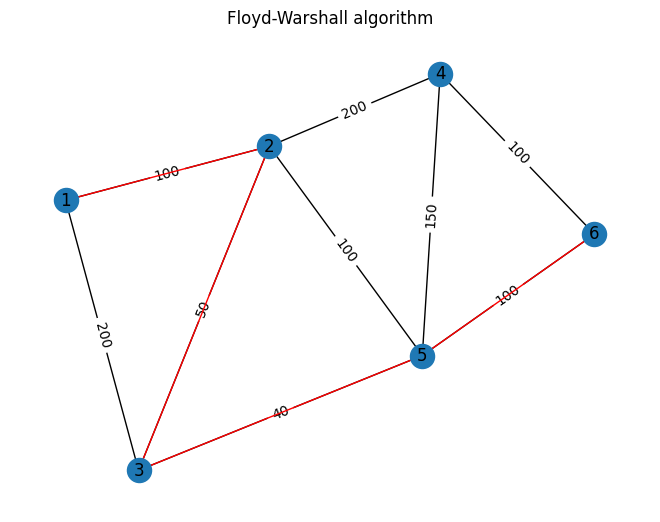

Floyd-Warshall algorithm
The nodes of the shortest path are: ['1', '2', '3', '5', '6']
The total lenght of the shortest path is: 290


In [ ]:
# Important: data, functions and graph already created in previous cell

# Problem resolution
# Floyd-Warshall algorithm
vsStartingNode = "1"
vsEndingNode = "6"
vlstShortestPath = []
vsGraphTitle = "Floyd-Warshall algorithm"
## Built-in function returns 2 dictionaries (predecessors and distances)
vdicPredecessors, vdicDistances = nx.floyd_warshall_predecessor_and_distance(G)

# Show result
## Nodes of the shortest path
vlstShortestPath = nx.reconstruct_path(vsStartingNode, vsEndingNode, vdicPredecessors)
vlstEdgesPath = mlstCreateEdgesFromPath(vlstShortestPath)
mbDrawGraph(G, vlstEdgesPath, vsGraphTitle)
print("Floyd-Warshall algorithm")
print("The nodes of the shortest path are: "+ str(vlstShortestPath))

## Lenght of the shortest path
viTotalLenght = vdicDistances[vsStartingNode][vsEndingNode]
print("The total lenght of the shortest path is: "+ str(viTotalLenght))

# Other data
vsGraphTitle = "Dijkstra's algorithm"


# Ejercicios

## Ejercicio 1

La red de la figura 6.17 presenta las distancias en millas entre pares de ciudades 1,2,…,8.
Use el algoritmo de Dijkstra para determinar la ruta más corta entre las siguientes ciudades y su distancia total, asi como su gráfico con la ruta mas corta:

* (a) Ciudades 1 y 8
* (b) Ciudades 1 y 6
* (c) Ciudades 4 y 8
* (d) Ciudades 2 y 6

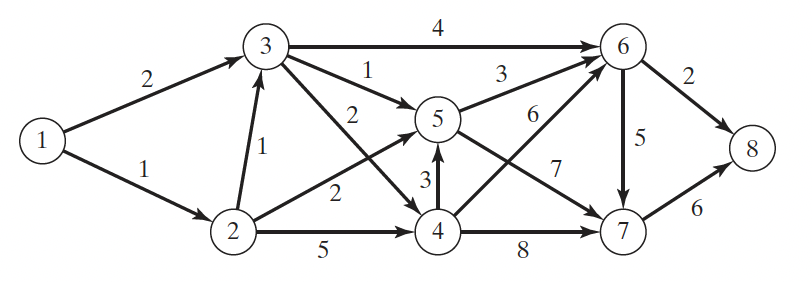

## Ejercicio 2
Para la red de la siguiente figura, halle las rutas más cortas y distancias entre cada los siguientes nodos.usando el algoritmo de Floyd-Warshall.

 Las distancias (en millas) se dan en los arcos. El arco (3,5) es direccional, es decir, no se permite el tráfico del nodo 5 al nodo 3.Todos los demás arcos permiten el tráfico en dos direcciones.

 * (a) Entre nodo 1 y nodo 5
 * (b) Entre nodo 1 y nodo 3
 * (c) Entre nodo 2 y nodo 5
 * (d) Muestre el grafico de la ruta mas corta entre el nodo 1 y el nodo 5

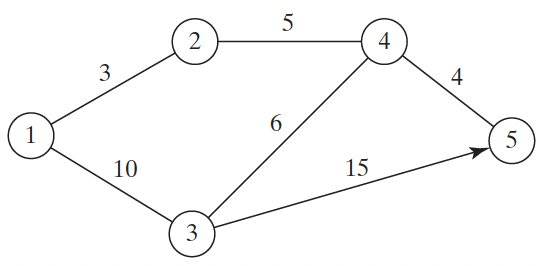

## Ejercicio 3
Una compañía aérea local piensa comprar un tractor nuevo para mover el tren de carros que llevan y traen el equipaje de los aviones que aterrizan en un pequeño aeropuerto que está en pleno crecimiento. Dentro de tres años se instalará un nuevo sistema mecanizado de transporte de equipaje, por lo que después no se necesitará el tractor. No obstante, tendrá una carga de trabajo pesada ylos costos de operación y mantenimiento aumentarán rápido y podría
resultar costeable reemplazarlo en uno o dos años. La siguiente tabla
proporciona los costos descontados netos totales asociados con la
compra del tractor (precio de compra menos valor de venta del tractor
en uso más costos de operación y mantenimiento) al final del año i y si se reemplaza al final del año j (donde el momento presente es el
año 0).

El problema es determinar en qué momento (si existe) debe reemplazarse el tractor para minimizar el costo total durante los tres años.

* Formule éste como un problema de ruta más corta y grafique la solución con el costo total

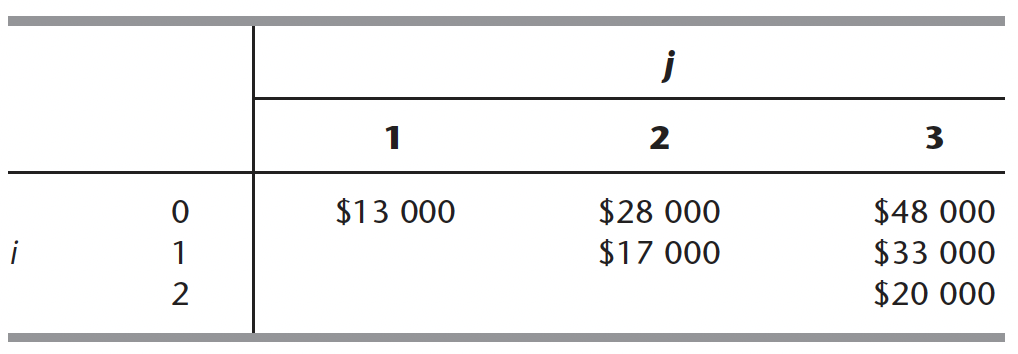